In [1]:
"""Visualise teaching positions and monthly workload for one semester.

The script produces:

1. A Gantt chart showing the duration of each teaching position.
2. A monthly bar chart showing the total expected workload.

Expected hours are distributed uniformly across every calendar day between
the start and end dates, including both boundary dates.

Users normally only need to edit the configuration section immediately below.

The required packages can be installed with:
python -m pip install matplotlib pandas
"""

# =============================================================================
# LIBRARY IMPORTS
# =============================================================================

from pathlib import Path
from typing import TypeAlias

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import (
    LinearSegmentedColormap,
    Normalize,
    to_rgb,
)

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# For Semester 1, YEAR is the year in which September occurs.
# Example: YEAR = 2026 represents September 2026 to January 2027.
#
# For Semester 2, YEAR is the calendar year containing the whole semester.
# Example: YEAR = 2027 represents January 2027 to May 2027.
YEAR = 2026
SEMESTER = 1

# Enter dates using UK date format: DD/MM/YYYY.
#
# Each entry represents one position. Positions belonging to the same course
# receive different tints of the same base colour.
TASKS = [
    {
        "course": "Course One",
        "position": "Demonstrator",
        "hours": 12,
        "start": "28/09/2026",
        "end": "23/10/2026",
    },
    {
        "course": "Course One",
        "position": "Tutor",
        "hours": 24,
        "start": "26/10/2026",
        "end": "20/11/2026",
    },
    {
        "course": "Course Two",
        "position": "Tutor",
        "hours": 7,
        "start": "16/11/2026",
        "end": "27/11/2026",
    },
    {
        "course": "Course Two",
        "position": "Marker",
        "hours": 24,
        "start": "30/11/2026",
        "end": "08/01/2027",
    },
    {
        "course": "Course Three",
        "position": "Demonstrator",
        "hours": 30,
        "start": "28/09/2026",
        "end": "04/12/2026",
    },
]

FIGURE_TITLE = "Course Timelines and Monthly Workload Distribution"
FIGURE_SIZE = (12, 10)

# Base colour used for the monthly workload gradient.
WORKLOAD_BASE_COLOUR = "#7d3c98"

# Enter a filename to save the figure, or use None to disable saving.
# Supported examples include "workload.png", "workload.pdf" and "workload.svg".
OUTPUT_FILE = "teaching_workload_semester_1_2026.png"
OUTPUT_DPI = 300

Figure saved to: /Users/mvmalyi/Documents/GitHub/scada-alarms-restructuting-and-analysis/teaching_workload_semester_1_2026.png


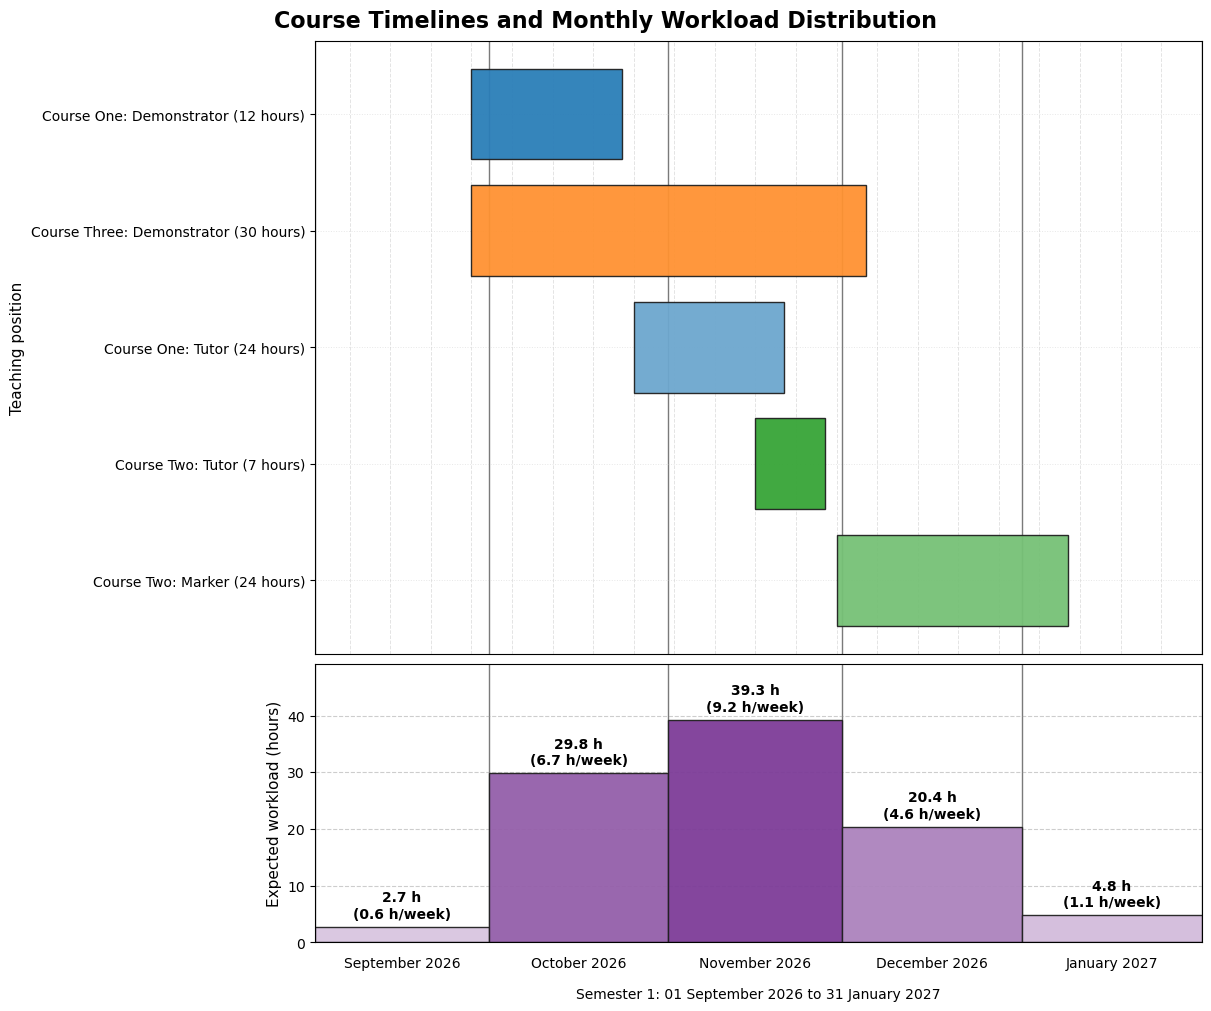

In [3]:
# =============================================================================
# TYPE DEFINITIONS
# =============================================================================

RGBColour: TypeAlias = tuple[float, float, float]
PositionKey: TypeAlias = tuple[str, str]


# =============================================================================
# DATA PREPARATION
# =============================================================================


def get_semester_bounds(
    year: int,
    semester: int,
) -> tuple[pd.Timestamp, pd.Timestamp]:
    """Return the inclusive start and end dates for a semester.

    Args:
        year: Calendar year associated with the semester.
        semester: Semester number, either 1 or 2.

    Returns:
        A tuple containing the inclusive semester start and end dates.

    Raises:
        ValueError: If the semester is not 1 or 2.
    """
    if semester == 1:
        start = pd.Timestamp(year=year, month=9, day=1)
        end = pd.Timestamp(year=year + 1, month=1, day=31)
    elif semester == 2:
        start = pd.Timestamp(year=year, month=1, day=1)
        end = pd.Timestamp(year=year, month=5, day=31)
    else:
        raise ValueError(
            f"SEMESTER must be 1 or 2, but {semester!r} was supplied."
        )

    return start, end


def prepare_task_data(
    task_records: list[dict[str, object]],
    semester_start: pd.Timestamp,
    semester_end: pd.Timestamp,
) -> pd.DataFrame:
    """Convert task records into a validated DataFrame.

    Args:
        task_records: User-supplied teaching position records.
        semester_start: Inclusive first date of the selected semester.
        semester_end: Inclusive final date of the selected semester.

    Returns:
        A validated DataFrame sorted chronologically by start date.

    Raises:
        ValueError: If records are missing, invalid or outside the semester.
    """
    if not task_records:
        raise ValueError("TASKS must contain at least one teaching position.")

    required_columns = {
        "course",
        "position",
        "hours",
        "start",
        "end",
    }

    data = pd.DataFrame(task_records)
    missing_columns = required_columns.difference(data.columns)

    if missing_columns:
        missing_text = ", ".join(sorted(missing_columns))
        raise ValueError(
            f"The following required TASKS fields are missing: {missing_text}."
        )

    data = data.loc[:, sorted(required_columns)].copy()

    data["course"] = data["course"].astype(str).str.strip()
    data["position"] = data["position"].astype(str).str.strip()
    data["hours"] = pd.to_numeric(data["hours"], errors="raise")
    data["start"] = pd.to_datetime(
        data["start"],
        format="%d/%m/%Y",
        errors="raise",
    )
    data["end"] = pd.to_datetime(
        data["end"],
        format="%d/%m/%Y",
        errors="raise",
    )

    if data["course"].eq("").any():
        raise ValueError("Every task must have a non-empty course name.")

    if data["position"].eq("").any():
        raise ValueError("Every task must have a non-empty position name.")

    if data["hours"].le(0).any():
        raise ValueError("Every task must have a positive number of hours.")

    invalid_date_order = data["end"] < data["start"]

    if invalid_date_order.any():
        invalid_rows = data.index[invalid_date_order].tolist()
        raise ValueError(
            "The end date occurs before the start date in TASKS rows "
            f"{invalid_rows}."
        )

    outside_semester = (
        data["start"].lt(semester_start)
        | data["end"].gt(semester_end)
    )

    if outside_semester.any():
        invalid_tasks = data.loc[
            outside_semester,
            ["course", "position", "start", "end"],
        ]

        task_descriptions = [
            (
                f"{row.course}: {row.position}, "
                f"{row.start:%d/%m/%Y} to {row.end:%d/%m/%Y}"
            )
            for row in invalid_tasks.itertuples()
        ]

        descriptions = "\n".join(
            f"    * {description}" for description in task_descriptions
        )

        raise ValueError(
            "The following positions fall outside the selected semester:\n"
            f"{descriptions}\n"
            f"Selected semester: {semester_start:%d/%m/%Y} to "
            f"{semester_end:%d/%m/%Y}."
        )

    data["duration_days"] = (
        data["end"] - data["start"]
    ).dt.days + 1

    data["hours_per_day"] = data["hours"] / data["duration_days"]

    data["label"] = data.apply(
        lambda row: (
            f"{row['course']}: {row['position']} "
            f"({row['hours']:g} hours)"
        ),
        axis=1,
    )

    return data.sort_values(
        by=["start", "end", "course", "position"],
        ascending=True,
    ).reset_index(drop=True)


def calculate_monthly_workload(
    tasks: pd.DataFrame,
    semester_start: pd.Timestamp,
    semester_end: pd.Timestamp,
) -> pd.Series:
    """Calculate workload totals for every month in the semester.

    Hours are distributed uniformly across all calendar days covered by each
    position. Weekends and weekdays are treated equally.

    Args:
        tasks: Validated teaching position data.
        semester_start: Inclusive semester start date.
        semester_end: Inclusive semester end date.

    Returns:
        Monthly workload totals indexed by the first day of each month.
    """
    semester_dates = pd.date_range(
        start=semester_start,
        end=semester_end,
        freq="D",
    )

    daily_hours = pd.Series(
        data=0.0,
        index=semester_dates,
        dtype=float,
    )

    for task in tasks.itertuples():
        task_dates = pd.date_range(
            start=task.start,
            end=task.end,
            freq="D",
        )

        daily_hours.loc[task_dates] += task.hours_per_day

    monthly_hours = daily_hours.resample("MS").sum()

    month_starts = pd.date_range(
        start=semester_start,
        end=semester_end,
        freq="MS",
    )

    return monthly_hours.reindex(month_starts, fill_value=0.0)


# =============================================================================
# COLOUR GENERATION
# =============================================================================


def blend_with_white(
    colour: str | RGBColour,
    white_fraction: float,
) -> RGBColour:
    """Blend a colour with white to create a lighter tint.

    Args:
        colour: Any Matplotlib-compatible colour or RGB tuple.
        white_fraction: Proportion of white, between 0 and 1.

    Returns:
        The resulting RGB colour.

    Raises:
        ValueError: If white_fraction is outside the interval from 0 to 1.
    """
    if not 0.0 <= white_fraction <= 1.0:
        raise ValueError("white_fraction must be between 0 and 1.")

    red, green, blue = to_rgb(colour)

    return (
        red + (1.0 - red) * white_fraction,
        green + (1.0 - green) * white_fraction,
        blue + (1.0 - blue) * white_fraction,
    )


def create_position_colours(
    tasks: pd.DataFrame,
) -> dict[PositionKey, RGBColour]:
    """Assign related colours to positions within the same course.

    Each course receives a base colour from Matplotlib's categorical palette.
    Different positions within that course receive lighter or darker tints of
    the same base colour.

    Args:
        tasks: Validated teaching position data.

    Returns:
        A mapping from course-position pairs to RGB colours.
    """
    course_names = list(dict.fromkeys(tasks["course"]))
    palette = plt.get_cmap("tab10").colors

    colours: dict[PositionKey, RGBColour] = {}

    for course_number, course_name in enumerate(course_names):
        base_colour = palette[course_number % len(palette)]

        course_positions = tasks.loc[
            tasks["course"].eq(course_name),
            "position",
        ]

        position_names = list(dict.fromkeys(course_positions))

        if len(position_names) == 1:
            tint_values = [0.15]
        else:
            tint_step = 0.30 / (len(position_names) - 1)
            tint_values = [
                0.05 + position_number * tint_step
                for position_number in range(len(position_names))
            ]

        for position_name, tint in zip(
            position_names,
            tint_values,
            strict=True,
        ):
            key = (course_name, position_name)
            colours[key] = blend_with_white(base_colour, tint)

    return colours


def create_workload_colours(
    monthly_hours: pd.Series,
    base_colour: str,
) -> list[tuple[float, float, float, float]]:
    """Create a light-to-dark workload colour gradient.

    Args:
        monthly_hours: Monthly workload totals.
        base_colour: Base Matplotlib-compatible colour.

    Returns:
        One RGBA colour for each monthly value.
    """
    light_colour = blend_with_white(base_colour, 0.75)

    colour_map = LinearSegmentedColormap.from_list(
        "monthly_workload",
        [light_colour, to_rgb(base_colour)],
    )

    maximum_hours = float(monthly_hours.max())
    normaliser = Normalize(
        vmin=0.0,
        vmax=max(maximum_hours, 1.0),
    )

    return [
        colour_map(normaliser(float(hours)))
        for hours in monthly_hours
    ]


# =============================================================================
# PLOTTING
# =============================================================================


def add_time_grid(
    axis: plt.Axes,
    month_starts: pd.DatetimeIndex,
    semester_end_exclusive: pd.Timestamp,
    include_weeks: bool,
) -> None:
    """Add month boundaries and optional weekly grid lines.

    Args:
        axis: Matplotlib axis receiving the grid.
        month_starts: First day of every displayed month.
        semester_end_exclusive: First day after the semester.
        include_weeks: Whether to include light weekly grid lines.
    """
    month_boundaries = month_starts.append(
        pd.DatetimeIndex([semester_end_exclusive])
    )

    if include_weeks:
        weekly_dates = pd.date_range(
            start=month_starts[0],
            end=semester_end_exclusive,
            freq="W-MON",
        )

        for date in weekly_dates:
            axis.axvline(
                date,
                color="#b0b0b0",
                linestyle="--",
                linewidth=0.7,
                alpha=0.35,
                zorder=0,
            )

    for date in month_boundaries:
        axis.axvline(
            date,
            color="#333333",
            linestyle="-",
            linewidth=1.0,
            alpha=0.65,
            zorder=1,
        )


def plot_workload(
    tasks: pd.DataFrame,
    monthly_hours: pd.Series,
    semester_start: pd.Timestamp,
    semester_end: pd.Timestamp,
    semester: int,
    title: str,
) -> plt.Figure:
    """Create the Gantt chart and monthly workload chart.

    Args:
        tasks: Validated teaching position data.
        monthly_hours: Monthly expected workload totals.
        semester_start: Inclusive semester start date.
        semester_end: Inclusive semester end date.
        semester: Semester number.
        title: Main figure title.

    Returns:
        The completed Matplotlib figure.
    """
    semester_end_exclusive = semester_end + pd.Timedelta(days=1)
    month_starts = monthly_hours.index
    next_month_starts = month_starts + pd.offsets.MonthBegin(1)

    month_widths = (
        next_month_starts - month_starts
    ).days.to_numpy()

    month_centres = month_starts + pd.to_timedelta(
        month_widths / 2,
        unit="D",
    )

    position_colours = create_position_colours(tasks)
    workload_colours = create_workload_colours(
        monthly_hours,
        WORKLOAD_BASE_COLOUR,
    )

    figure, (gantt_axis, workload_axis) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=FIGURE_SIZE,
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.0]},
        constrained_layout=True,
    )

    figure.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
    )

    # -------------------------------------------------------------------------
    # Gantt chart
    # -------------------------------------------------------------------------

    y_positions = list(range(len(tasks)))

    for y_position, task in zip(
        y_positions,
        tasks.itertuples(),
        strict=True,
    ):
        colour_key = (task.course, task.position)

        gantt_axis.barh(
            y=y_position,
            width=task.duration_days,
            left=task.start,
            height=0.78,
            color=position_colours[colour_key],
            edgecolor="#202020",
            linewidth=1.0,
            alpha=0.95,
            zorder=2,
        )

    gantt_axis.set_yticks(y_positions)
    gantt_axis.set_yticklabels(tasks["label"])
    gantt_axis.invert_yaxis()
    gantt_axis.set_ylabel("Teaching position", fontsize=11)
    gantt_axis.tick_params(
        axis="x",
        which="both",
        bottom=False,
        labelbottom=False,
    )
    gantt_axis.grid(
        axis="y",
        color="#d0d0d0",
        linestyle=":",
        linewidth=0.7,
        alpha=0.5,
    )

    add_time_grid(
        axis=gantt_axis,
        month_starts=month_starts,
        semester_end_exclusive=semester_end_exclusive,
        include_weeks=True,
    )

    # -------------------------------------------------------------------------
    # Monthly workload chart
    # -------------------------------------------------------------------------

    workload_axis.bar(
        x=month_starts,
        height=monthly_hours.to_numpy(),
        width=month_widths,
        align="edge",
        color=workload_colours,
        edgecolor="#202020",
        linewidth=1.0,
        alpha=0.95,
        zorder=2,
    )

    maximum_hours = float(monthly_hours.max())
    label_offset = max(maximum_hours * 0.025, 0.25)

    for month_centre, hours, days_in_month in zip(
        month_centres,
        monthly_hours,
        month_widths,
        strict=True,
    ):
        # Convert the monthly workload into an average weekly workload using
        # the actual number of calendar days in the corresponding month.
        average_weekly_hours = float(hours) * 7 / days_in_month

        workload_axis.text(
            x=month_centre,
            y=float(hours) + label_offset,
            s=(
                f"{hours:.1f} h\n"
                f"({average_weekly_hours:.1f} h/week)"
            ),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontsize=10,
            fontweight="bold",
            linespacing=1.25,
            clip_on=False,
        )

    workload_axis.set_ylabel(
        "Expected workload (hours)",
        fontsize=11,
    )
    workload_axis.set_xlabel(
        f"Semester {semester}: "
        f"{semester_start:%d %B %Y} to {semester_end:%d %B %Y}",
        fontsize=10,
        labelpad=12,
    )

    workload_axis.set_xticks(month_centres)
    workload_axis.set_xticklabels(
        [date.strftime("%B %Y") for date in month_starts],
        rotation=0,
        horizontalalignment="center",
    )
    workload_axis.tick_params(
        axis="x",
        which="both",
        length=0,
        pad=10,
    )

    workload_axis.grid(
        axis="y",
        color="#909090",
        linestyle="--",
        linewidth=0.8,
        alpha=0.45,
        zorder=0,
    )

    add_time_grid(
        axis=workload_axis,
        month_starts=month_starts,
        semester_end_exclusive=semester_end_exclusive,
        include_weeks=False,
    )

    # Additional vertical space accommodates both lines of each workload label.
    workload_axis.set_ylim(
        bottom=0.0,
        top=max(maximum_hours * 1.25, 1.0),
    )

    # Setting the limits to the complete semester ensures that the first and
    # last months are displayed at their full calendar widths.
    workload_axis.set_xlim(
        semester_start,
        semester_end_exclusive,
    )

    gantt_axis.xaxis_date()
    workload_axis.xaxis_date()

    # Prevent Matplotlib from adding horizontal margins beyond the semester.
    gantt_axis.margins(x=0)
    workload_axis.margins(x=0)

    return figure


# =============================================================================
# MAIN PROGRAM
# =============================================================================


def main() -> None:
    """Validate the configuration, calculate workloads and create the chart."""
    semester_start, semester_end = get_semester_bounds(
        year=YEAR,
        semester=SEMESTER,
    )

    tasks = prepare_task_data(
        task_records=TASKS,
        semester_start=semester_start,
        semester_end=semester_end,
    )

    monthly_hours = calculate_monthly_workload(
        tasks=tasks,
        semester_start=semester_start,
        semester_end=semester_end,
    )

    figure = plot_workload(
        tasks=tasks,
        monthly_hours=monthly_hours,
        semester_start=semester_start,
        semester_end=semester_end,
        semester=SEMESTER,
        title=FIGURE_TITLE,
    )

    if OUTPUT_FILE is not None:
        output_path = Path(OUTPUT_FILE)
        output_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        figure.savefig(
            output_path,
            dpi=OUTPUT_DPI,
            bbox_inches="tight",
        )

        print(f"Figure saved to: {output_path.resolve()}")

    plt.show()


if __name__ == "__main__":
    main()
